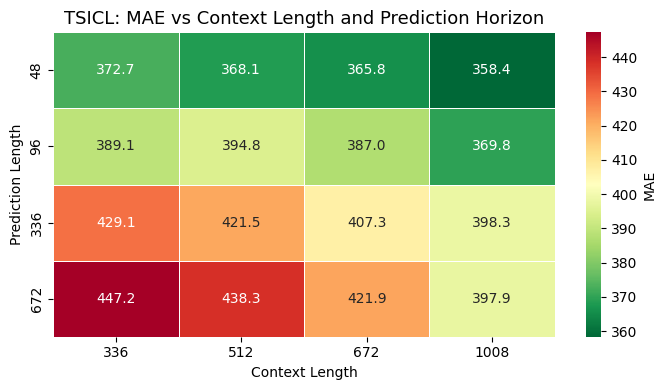

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load your results
df = pd.read_csv("/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun/summary_all_runs.csv")

# Select model
model_name = "TSICL"   # change to Chronos-2

model_df = df[df["model"] == model_name]


# Choose metric
metric = "mae"   # change to "crps" or "wql"


# Create pivot table
heatmap_data = (
    model_df
    .pivot(
        index="prediction_length",
        columns="context_length",
        values=metric
    )
    .sort_index()
)


# Plot
plt.figure(figsize=(7, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": metric.upper()}
)

plt.title(
    f"{model_name}: {metric.upper()} vs Context Length and Prediction Horizon",
    fontsize=13
)

plt.xlabel("Context Length")
plt.ylabel("Prediction Length")

plt.tight_layout()

plt.savefig(
    f"{model_name}_{metric}_context_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

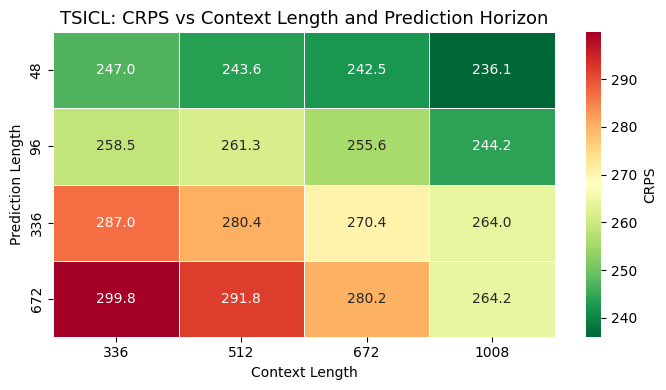

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load your results
df = pd.read_csv("/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun/summary_all_runs.csv")

# Select model
model_name = "TSICL"   # change to Chronos-2

model_df = df[df["model"] == model_name]


# Choose metric
metric = "crps"   # change to "crps" or "wql"


# Create pivot table
heatmap_data = (
    model_df
    .pivot(
        index="prediction_length",
        columns="context_length",
        values=metric
    )
    .sort_index()
)


# Plot
plt.figure(figsize=(7, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": metric.upper()}
)

plt.title(
    f"{model_name}: {metric.upper()} vs Context Length and Prediction Horizon",
    fontsize=13
)

plt.xlabel("Context Length")
plt.ylabel("Prediction Length")

plt.tight_layout()

plt.savefig(
    f"{model_name}_{metric}_context_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Removed 8 duplicate rows


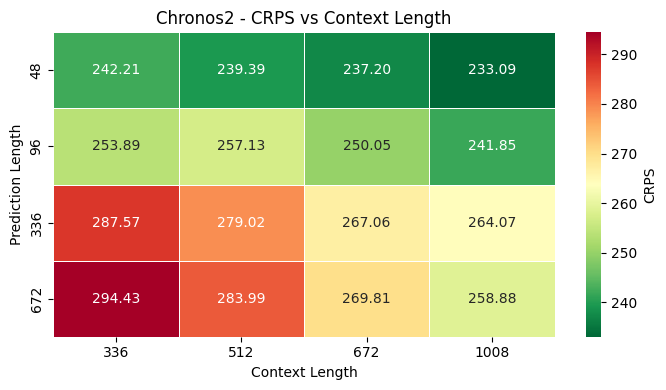

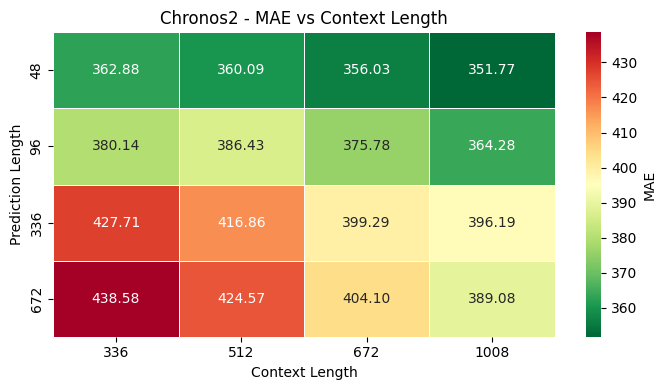

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================
# Load data
# ==========================
df = pd.read_csv("/home/d32485/forecasting_benchmark/outputs/chronos2/cer_bis/summary_all_runs.csv")


# ==========================
# Remove duplicate experiments
# ==========================
df_clean = (
    df.drop_duplicates(
        subset=[
            "model",
            "context_length",
            "prediction_length"
        ],
        keep="first"
    )
    .sort_values(
        [
            "model",
            "context_length",
            "prediction_length"
        ]
    )
)


print(
    f"Removed {len(df)-len(df_clean)} duplicate rows"
)


# ==========================
# Plot function
# ==========================
def plot_context_heatmap(
    df,
    model_name,
    metric
):

    model_df = df[
        df["model"] == model_name
    ]

    heatmap_data = (
        model_df
        .pivot(
            index="prediction_length",
            columns="context_length",
            values=metric
        )
        .sort_index()
    )


    plt.figure(
        figsize=(7,4)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={
            "label": metric.upper()
        }
    )


    plt.title(
        f"{model_name} - {metric.upper()} vs Context Length"
    )

    plt.xlabel(
        "Context Length"
    )

    plt.ylabel(
        "Prediction Length"
    )

    plt.tight_layout()


    plt.savefig(
        f"{model_name}_{metric}_context_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



# ==========================
# Generate Chronos2 plots
# ==========================

plot_context_heatmap(
    df_clean,
    "Chronos2",
    "crps"
)


plot_context_heatmap(
    df_clean,
    "Chronos2",
    "mae"
)

saved → outputs/analysis/plots/wql_vs_context_h96.png
model           Chronos2     TSICL    TiRex2
context_length                              
144             0.462336  0.501775  0.460349
336             0.495262  0.453798  0.444805
672             0.443966  0.454975  0.457484
1440            0.452542  0.651477  0.476121
2500            0.399050  0.408450  0.409280


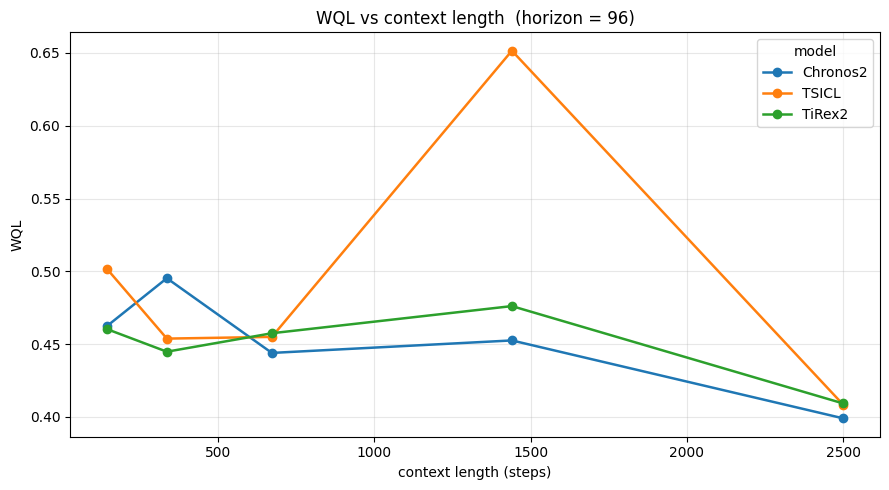

In [5]:
# scripts/analysis/plot_mase_vs_context.py
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
CSV_PATHS = [
    "/home/d32485/forecasting_benchmark/outputs/chronos2/cer_bis/multirun_2026-07-16_16-24-23/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun_2026-07-16_16-25-11/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tirex2/cer_bis/multirun_2026-07-16_16-25-42/summary_all_runs.csv",
    # "/home/d32485/forecasting_benchmark/outputs/patchtst/cer_bis/summary_all_runs.csv",
    # "/home/d32485/forecasting_benchmark/outputs/lgbm/cer_bis/summary_all_runs.csv"
]
FIXED_HORIZON = 96
METRIC = "wql"
OUT = Path("outputs/analysis/plots")
OUT.mkdir(parents=True, exist_ok=True)
# ----------------

dfs = []
for p in CSV_PATHS:
    p = Path(p)
    if p.exists():
        dfs.append(pd.read_csv(p))
    else:
        print(f"[warn] missing: {p}")
df = pd.concat(dfs, ignore_index=True)

# fixed horizon, drop duplicate runs (keep the latest per model×ctx)
df = df[df["prediction_length"] == FIXED_HORIZON].copy()
if "run_date" in df.columns:
    df = df.sort_values("run_date").drop_duplicates(
        subset=["model", "context_length", "prediction_length"], keep="last")

fig, ax = plt.subplots(figsize=(9, 5))
for model, g in df.groupby("model"):
    g = g.sort_values("context_length")
    ax.plot(g["context_length"], g[METRIC], marker="o", lw=1.8, label=model)

ax.set_xlabel("context length (steps)")
ax.set_ylabel(METRIC.upper())
ax.set_title(f"{METRIC.upper()} vs context length  (horizon = {FIXED_HORIZON})")
ax.legend(title="model")
ax.grid(True, alpha=0.3)
fig.tight_layout()

out_path = OUT / f"{METRIC}_vs_context_h{FIXED_HORIZON}.png"
fig.savefig(out_path, dpi=150)
print(f"saved → {out_path}")

# also print the underlying table
pivot = df.pivot_table(index="context_length", columns="model", values=METRIC)
print(pivot)
pivot.to_csv(OUT / f"{METRIC}_vs_context_h{FIXED_HORIZON}.csv")

In [5]:
# scripts/analysis/make_timing_table.py
from pathlib import Path
import pandas as pd

CSV_PATHS = [
    "/home/d32485/forecasting_benchmark/outputs/chronos2/cer_bis/multirun_2026-07-15_10-36-32/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun_2026-07-15_10-43-44/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tirex2/cer_bis/multirun_2026-07-15_10-52-20/summary_all_runs.csv",
]
FIXED_HORIZON = 96
OUT = Path("outputs/analysis/tables"); OUT.mkdir(parents=True, exist_ok=True)

df = pd.concat([pd.read_csv(p) for p in CSV_PATHS if Path(p).exists()], ignore_index=True)
df = df[df["prediction_length"] == FIXED_HORIZON]
if "run_date" in df.columns:
    df = df.sort_values("run_date").drop_duplicates(
        ["model", "context_length", "prediction_length"], keep="last")

cols = ["model", "context_length", "model_load_s", "total_eval_s",
        "pure_inference_s", "per_forecast_ms"]
cols = [c for c in cols if c in df.columns]
tbl = df[cols].sort_values(["model", "context_length"]).round(2)

# jolis noms de colonnes
rename = {
    "model": "Model", "context_length": "Context",
    "model_load_s": "Load (s)", "total_eval_s": "Eval (s)",
    "pure_inference_s": "Inference (s)", "per_forecast_ms": "ms / forecast",
}
tbl = tbl.rename(columns=rename)

latex = tbl.to_latex(
    index=False, escape=True,
    column_format="l" + "r" * (len(tbl.columns) - 1),
    caption=f"Inference and evaluation times (horizon = {FIXED_HORIZON}).",
    label="tab:timing",
)
(OUT / "timing_table.tex").write_text(latex)
print(latex)

\begin{table}
\caption{Inference and evaluation times (horizon = 96).}
\label{tab:timing}
\begin{tabular}{lrrrrr}
\toprule
Model & Context & Load (s) & Eval (s) & Inference (s) & ms / forecast \\
\midrule
Chronos2 & 144 & 7.250000 & 14.290000 & 5.230000 & 0.500000 \\
Chronos2 & 336 & 0.310000 & 13.160000 & 4.890000 & 0.510000 \\
Chronos2 & 672 & 0.140000 & 11.560000 & 4.310000 & 0.520000 \\
Chronos2 & 1440 & 0.140000 & 7.110000 & 2.690000 & 0.540000 \\
TSICL & 144 & 5.200000 & 22.610000 & 13.750000 & 1.320000 \\
TSICL & 336 & 0.590000 & 24.780000 & 16.590000 & 1.730000 \\
TSICL & 672 & 0.500000 & 27.450000 & 20.260000 & 2.430000 \\
TSICL & 1440 & 0.500000 & 27.780000 & 23.300000 & 4.660000 \\
TiRex2 & 144 & 6.940000 & 21.670000 & 12.110000 & 1.160000 \\
TiRex2 & 336 & 0.680000 & 19.780000 & 11.010000 & 1.150000 \\
TiRex2 & 672 & 0.740000 & 17.730000 & 9.990000 & 1.200000 \\
TiRex2 & 1440 & 0.770000 & 10.750000 & 6.030000 & 1.210000 \\
\bottomrule
\end{tabular}
\end{table}



In [4]:
import pandas as pd
from pathlib import Path

# ---- CONFIG ----
CSV_PATHS = [
    "/home/d32485/forecasting_benchmark/outputs/chronos2/cer_bis/multirun_2026-07-16_16-24-23/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun_2026-07-16_16-25-11/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/tirex2/cer_bis/multirun_2026-07-16_16-25-42/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/lgbm/cer_bis/ctx1440_h96/summary_all_runs.csv",
    "/home/d32485/forecasting_benchmark/outputs/statistical/cer_bis/2026-07-16_08-51-10/summary_by_model.csv,
    "/home/d32485/forecasting_benchmark/outputs/prophet/cer_bis/2026-07-19_22-49-02/summary_by_model.csv",
    "/home/d32485/forecasting_benchmark/outputs/patchtst/cer_bis/ctx1440_h96/2026-07-14_09-48-14/eval/summary_by_model.csv",
]
CTX, HORIZON = 1440, 96
METRICS = ["mae_normalized", "mase", "wql"]   # colonnes à afficher
DATASET = "cer_bis"
# ----------------

# collecte
dfs = []
for pat in CSV_PATHS:
    for f in Path(".").glob(pat):
        dfs.append(pd.read_csv(f))
df = pd.concat(dfs, ignore_index=True)

# filtre sur le setting fixe
sub = df[(df["context_length"] == CTX) & (df["prediction_length"] == HORIZON)]

# dédoublonne (garde le run le plus récent par modèle)
if "run_date" in sub.columns:
    sub = sub.sort_values("run_date").drop_duplicates("model", keep="last")

# table : modèles × métriques
cols = [c for c in METRICS if c in sub.columns]
tbl = sub.set_index("model")[cols].sort_values("mase").round(3)

# jolis noms de colonnes
rename = {
    "mae_normalized": "NMAE", "mase": "MASE",
    "wql": "WQL", "sql": "SQL",
}
tbl = tbl.rename(columns=rename)

# --- affichage écran ---
print(f"=== {DATASET} — ctx={CTX}, h={HORIZON} ===")
print(tbl.to_string())

# --- LaTeX ---
latex = tbl.to_latex(
    index=True,
    escape=True,
    column_format="l" + "r" * len(tbl.columns),
    caption=f"Point and probabilistic accuracy on {DATASET} "
            f"(context $=${CTX}, horizon $=${HORIZON}). Lower is better; "
            f"best per column in bold.",
    label=f"tab:results_{DATASET}_ctx{CTX}_h{HORIZON}",
    bold_rows=False,
)
print("\n" + latex)

# sauvegarde
out = Path("outputs/analysis/tables")
out.mkdir(parents=True, exist_ok=True)
(out / f"table_{DATASET}_ctx{CTX}_h{HORIZON}.tex").write_text(latex)

SyntaxError: unterminated string literal (detected at line 10) (3532928303.py, line 10)